In [1]:
import torch
import matplotlib.pyplot as plt

In [2]:
o = torch.load("./train1-smol.step5000.pt", map_location=torch.device('cpu'))
training_loss = o['training_loss']
training_loss = training_loss[training_loss != 0.0]

In [3]:
o.keys()

dict_keys(['model', 'optimizer', 'iteration', 'training_loss'])

In [4]:
from cs336_basics.model import lr_schedule_cosine_annealing

steps = 5000
warmup_steps = 200
lrs = torch.zeros([steps])
for i in range(steps):
    lrs[i] = lr_schedule_cosine_annealing(
            i, lr_max=1e-2, lr_min=5e-4, warmup_period=warmup_steps, annealing_period=steps
        )
lrs

tensor([0.0000e+00, 5.0000e-05, 1.0000e-04,  ..., 5.0001e-04, 5.0000e-04,
        5.0000e-04])

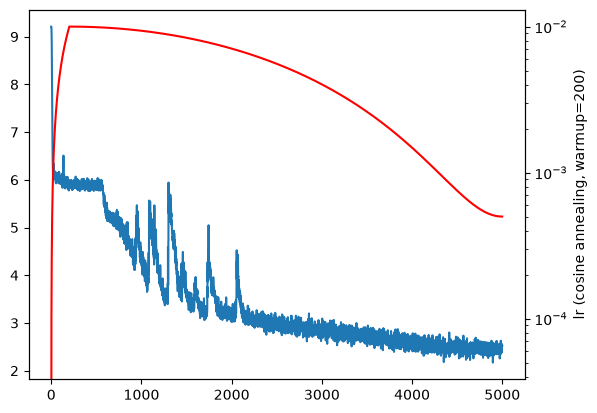

In [5]:
# https://matplotlib.org/stable/gallery/subplots_axes_and_figures/two_scales.html
fig, ax1 = plt.subplots()
ax1.plot(training_loss)


ax2 = ax1.twinx()
ax2.set_yscale('log')

ax2.set_ylabel('lr (cosine annealing, warmup=200)')
ax2.plot(lrs, color='red')
plt.show()